In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score,accuracy_score,confusion_matrix,ConfusionMatrixDisplay


In [87]:
df = pd.read_csv('shop_smart_ecommerce.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [88]:
df.shape

(12330, 18)

In [89]:
df.isna().sum() # hence cleaned data

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [91]:
print(df.groupby(df['VisitorType']).groups.keys())

dict_keys(['New_Visitor', 'Other', 'Returning_Visitor'])


# EDA

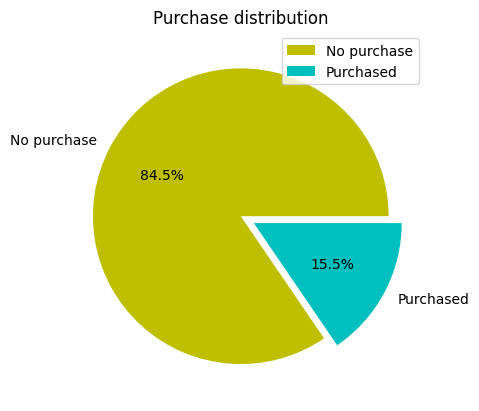

In [159]:
plt.pie(
    x = df['Revenue'].value_counts(),
    labels = ['No purchase','Purchased'],
    autopct = "%1.1f%%",
    colors = ['y','c'],
    explode = [0,0.1],
)
plt.title('Purchase distribution')
plt.legend(loc="upper right")
plt.savefig('Revenue_Distribution.png')
plt.show()

<Axes: xlabel='ProductRelated_Duration', ylabel='ProductRelated'>

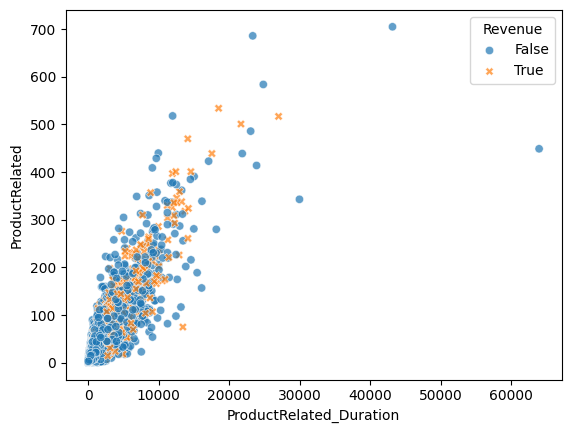

In [93]:
sns.scatterplot(
    data = df,
    y = 'ProductRelated',
    x = 'ProductRelated_Duration',
    style = 'Revenue',
    hue = 'Revenue',
    alpha = 0.7

)

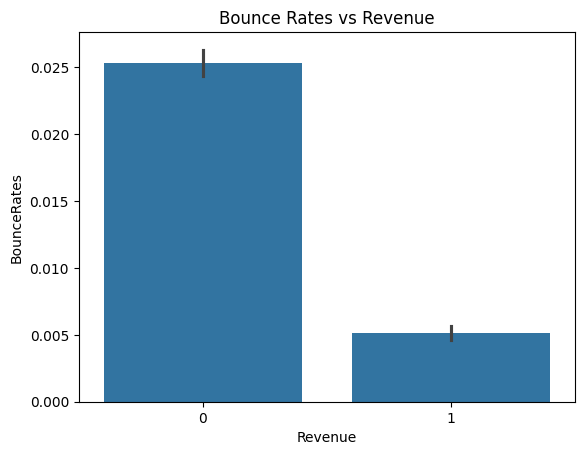

In [160]:
sns.barplot(
    data =df,
    y = 'BounceRates',
    x = 'Revenue'
)
plt.title('Bounce Rates vs Revenue')
plt.savefig('bounce_rates_vs_revenue.png')
plt.show()

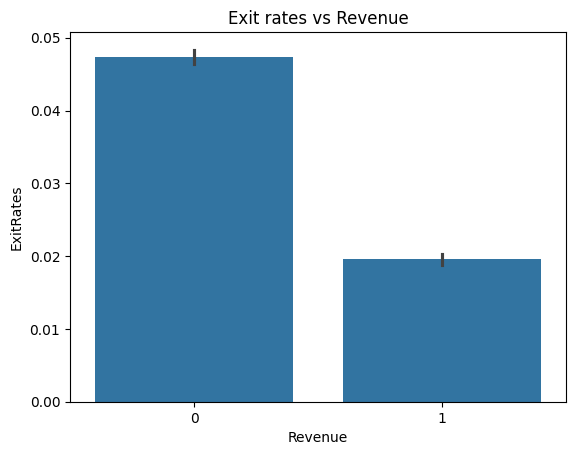

In [161]:
sns.barplot(
    data =df,
    y = 'ExitRates',
    x = 'Revenue'
)

plt.title('Exit rates vs Revenue')
plt.savefig('exit_rates_vs_revenue.png')
plt.show()

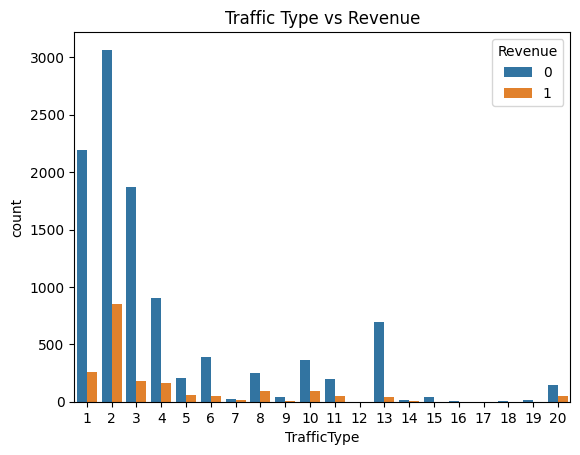

In [162]:
sns.countplot(
    x = df['TrafficType'],
    hue = df['Revenue']
)
plt.title('Traffic Type vs Revenue')
plt.savefig('traffic_type_vs_revenue.png')
plt.show()
#skewed data

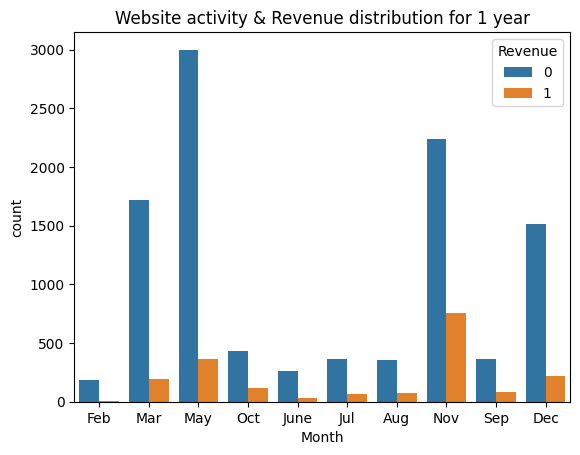

In [163]:
sns.countplot(
    data = df,
    x = 'Month',
    hue = 'Revenue'
)
plt.title('Website activity & Revenue distribution for 1 year')
plt.savefig('Website_activity_vs_revenue_distribution.png')
plt.show()

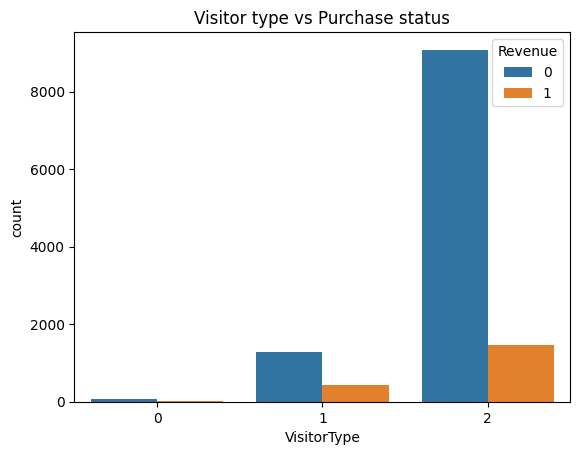

In [164]:
sns.countplot(
    data = df,
    x = 'VisitorType',
    hue = 'Revenue'
)
plt.title('Visitor type vs Purchase status')
plt.savefig('visitor_type_vs_revenue_distribution.png')
plt.show()

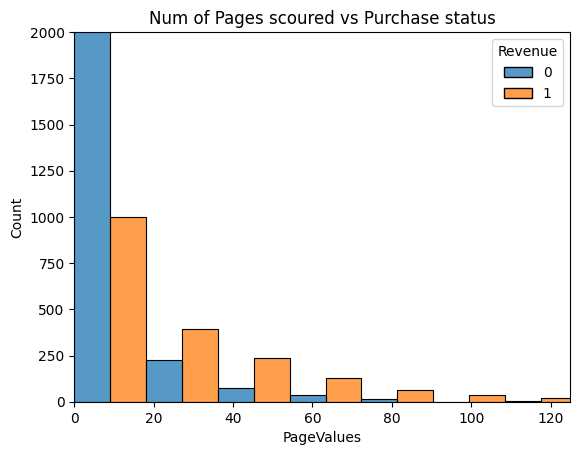

In [166]:
fig, ax = plt.subplots()

sns.histplot(
    data = df,
    x = 'PageValues',
    bins = 20,
    hue = 'Revenue',
    ax = ax,
    multiple = 'dodge'
)
ax.set_xlim(0,125)
ax.set_ylim(0,2000)
ax.set_title('Num of Pages scoured vs Purchase status')
plt.savefig('pages_visited_vs_revenue_dist.png')

#imp  higher num of pages values :: higher the chance of purchase

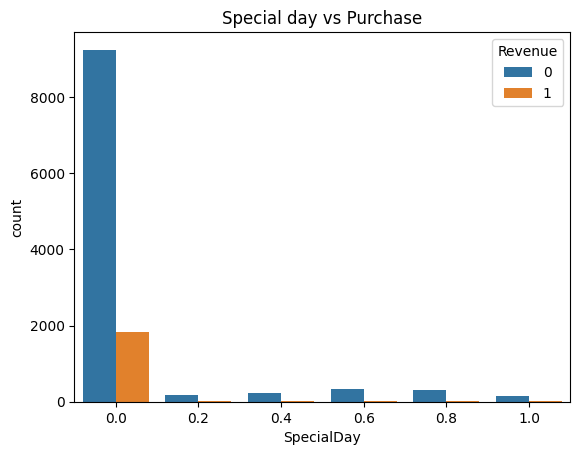

In [167]:
sns.countplot(
    data = df, 
    x = 'SpecialDay',
    hue = 'Revenue'
)

plt.title('Special day vs Purchase')

plt.savefig('special_day_revenue_distribution.png')

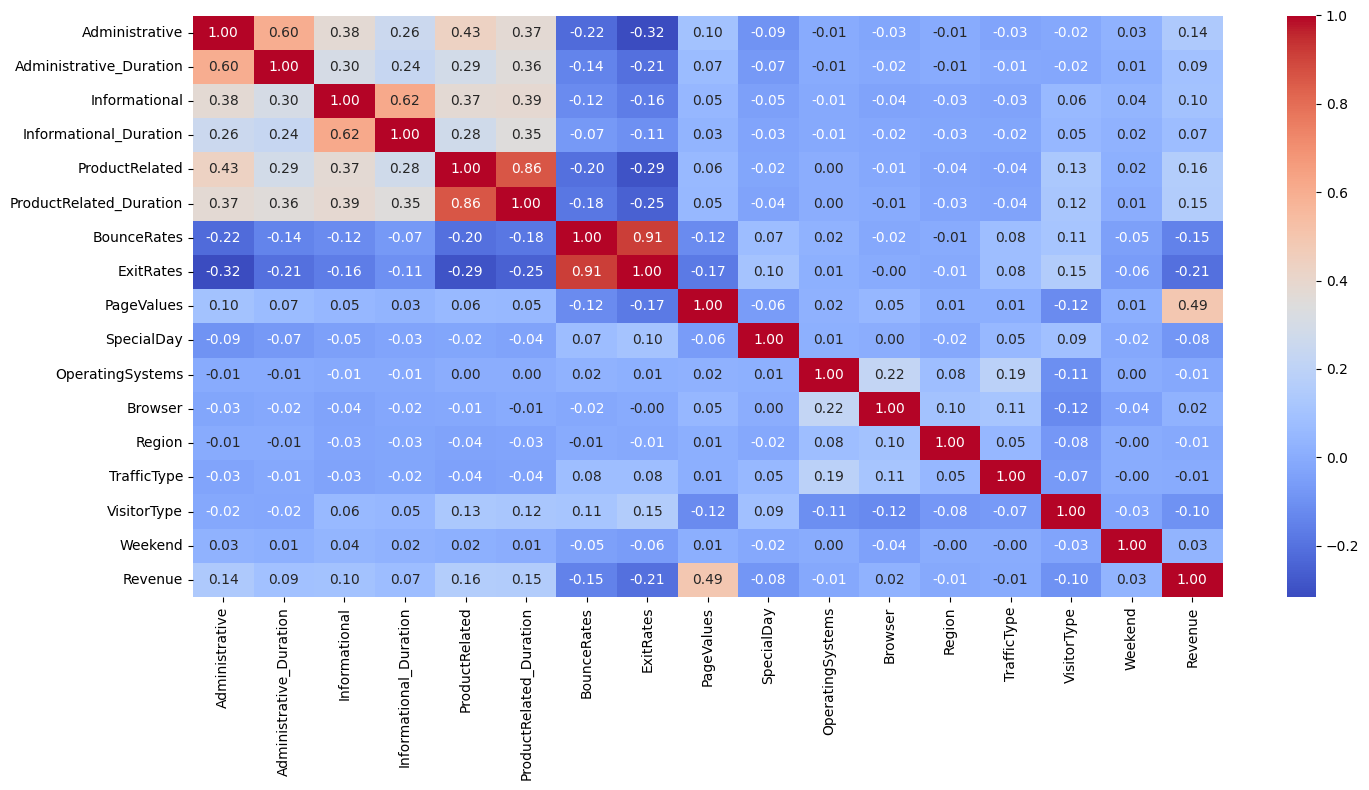

In [168]:
#correlation heatmap
num_cols = df.select_dtypes(
    include = 'number')

corr_matrix = num_cols.corr()

plt.figure(figsize = (15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm'
)

plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# Feature Engineering

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [103]:
#convert bool to int
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


In [104]:
df['VisitorType'] = df['VisitorType'].map({'Returning_Visitor': 2, 'New_Visitor': 1,'Other' : 0})
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,2,1,0


In [105]:
#train test split
X = df.drop('Revenue', axis = 1)
y = df['Revenue']

In [106]:
num_cols = X.select_dtypes(include = ["int64","float64"]).columns
cat_cols = X.select_dtypes(include = ["object","category"]).columns


In [107]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y
)

# Hyperparameter tuning

## Decision Tree

In [108]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

#preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers = [
    ("num",StandardScaler(),num_cols),
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols)
])

In [109]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state = 42)

In [110]:
from sklearn.pipeline import Pipeline

#pipeline
pipe_dt = Pipeline([
    ("preprocess",preprocessor),
    ("model",dt)
])


In [111]:
# cross validation for hyperparameter tuning

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier


param_grid_dt = {
    'model__max_depth': [5, 10,13],
    'model__min_samples_split': [2,7, 13 ,15],
    'model__ccp_alpha': [ 0.0001, 0.001, 0.005, 0.01],
    "model__min_samples_leaf": [20, 30, 50],
    "model__class_weight": ['balanced', None],
    'model__random_state':[42]
}


grid_dt = GridSearchCV(
    pipe_dt,
    param_grid_dt,
    cv = 5,
    scoring = "recall",
    n_jobs=-1,
    verbose=2
)

grid_dt.fit(X_train,y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__ccp_alpha': [0.0001, 0.001, ...], 'model__class_weight': ['balanced', None], 'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [20, 30, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [113]:
print(grid_dt.best_params_)

{'model__ccp_alpha': 0.001, 'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 50, 'model__min_samples_split': 2, 'model__random_state': 42}


In [125]:
best_model_dt = grid_dt.best_estimator_

y_pred_dt = best_model_dt.predict(X_test)

print("Decision Tree Classifier\n")

print("f1_score : ", f1_score(y_test,y_pred_dt))
print("acc_score: ", accuracy_score(y_test,y_pred_dt))
print("precision : ", precision_score(y_test,y_pred_dt))
print("recall : ", recall_score(y_test,y_pred_dt))
print("ROC_AUC : ", roc_auc_score(y_test,y_pred_dt))

print("\nConfusion matrix:\n", confusion_matrix(y_test,y_pred_dt))

Decision Tree Classifier

f1_score :  0.6029411764705882
acc_score:  0.8248175182481752
precision :  0.4641509433962264
recall :  0.8601398601398601
ROC_AUC :  0.8392480560692905

Confusion matrix:
 [[2559  568]
 [  80  492]]


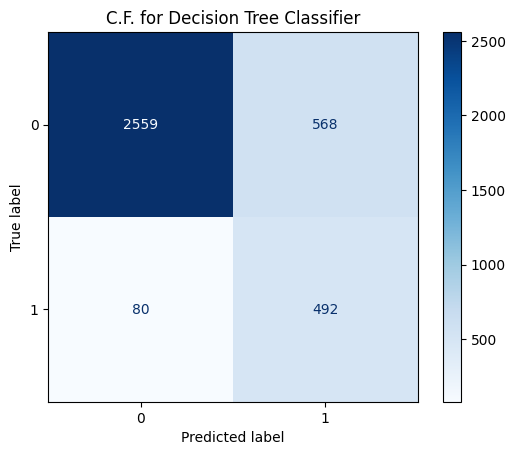

In [169]:
#confusion matrix plot
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap="Blues")
plt.title("C.F. for Decision Tree Classifier")
plt.savefig('cf_decision_tree.png')
plt.show()

In [115]:
from sklearn import tree

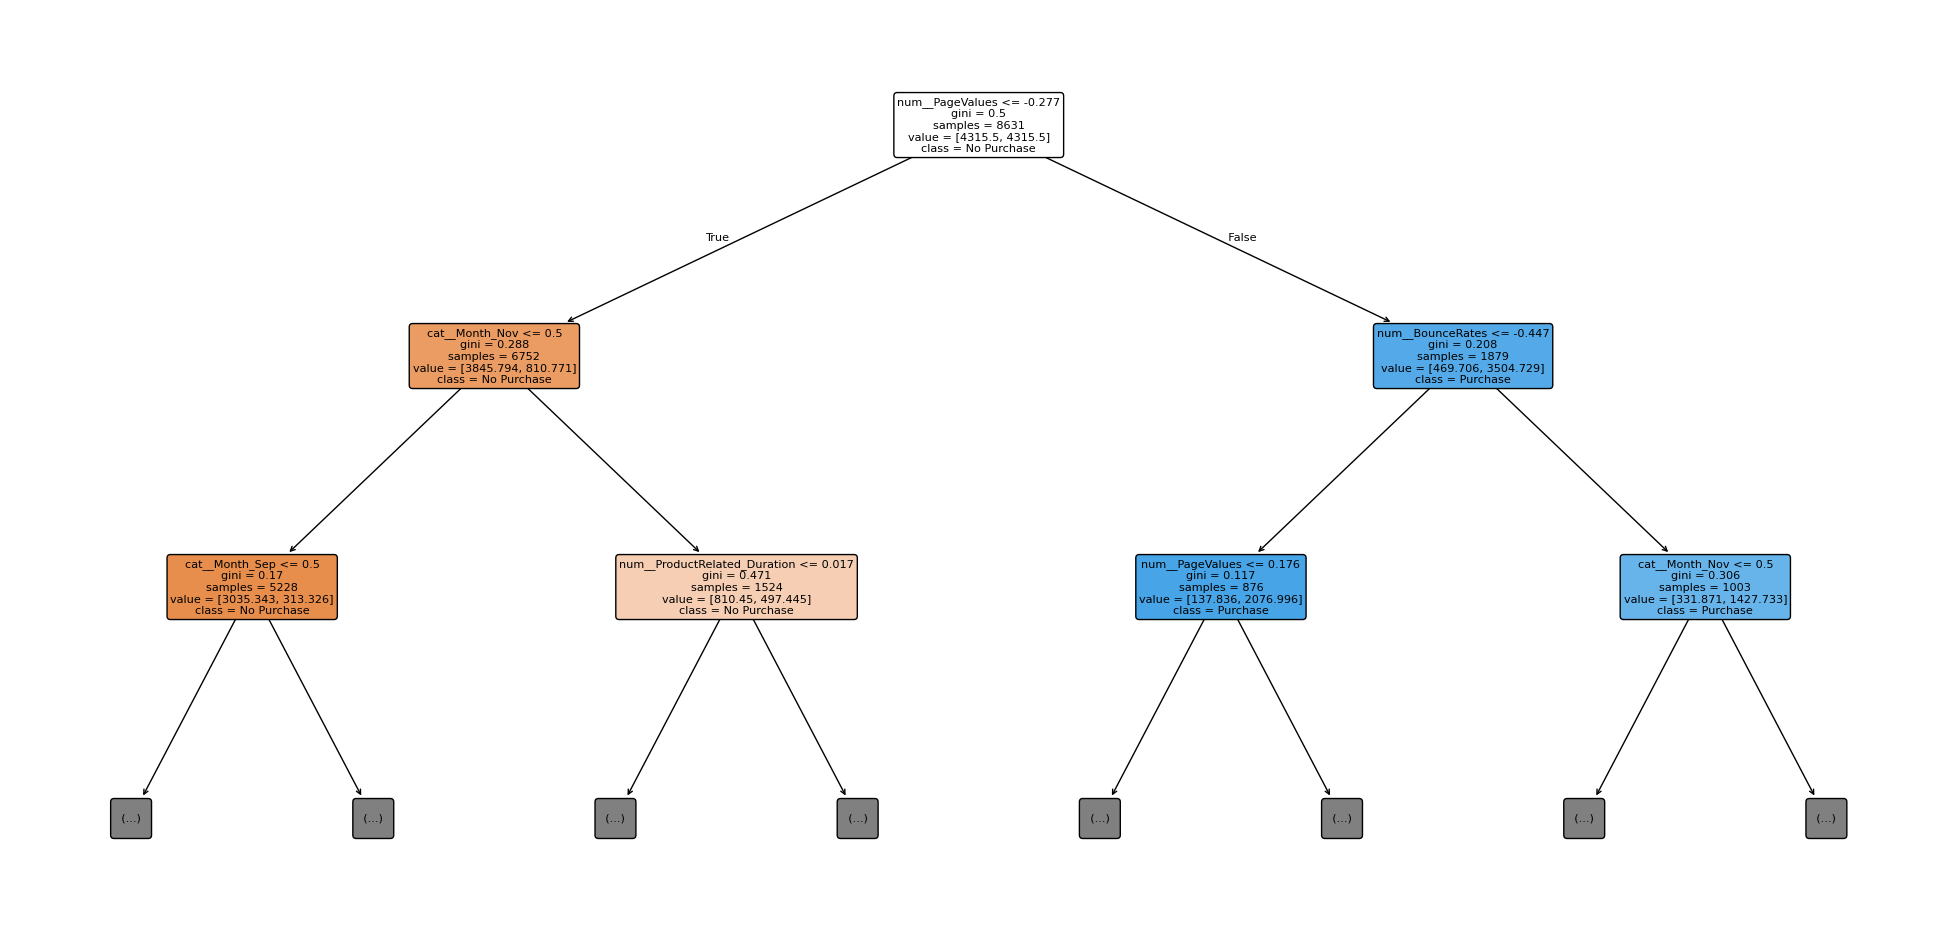

In [140]:
preprocessor = best_model_dt.named_steps['preprocess']
dt_steps = best_model_dt.named_steps['model']

feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(25,12))

tree.plot_tree(
    dt_steps,
    feature_names=feature_names,
    class_names=['No Purchase', 'Purchase'],
    filled=True,
    rounded=True,
    max_depth = 2
)

plt.show()

## SVM classifier

In [118]:
from sklearn.svm import SVC

svc = SVC()

In [119]:
from sklearn.pipeline import Pipeline

#pipeline
pipe_svc = Pipeline([
    ("preprocess",preprocessor),
    ("model",svc)
])


In [120]:
from sklearn.model_selection import GridSearchCV


param_grid_svc = {
    "model__C" : [0.0005,0.001,0.1,0.2,0.6,0.8,1],
    "model__kernel" : ['rbf','poly','linear','sigmoid'],
    "model__class_weight" : ['balanced', None]
}

grid_svc = GridSearchCV(
    pipe_svc, 
    param_grid_svc,
    n_jobs = -1,
    scoring = 'recall',
    cv = 5, 
    verbose = 2
)


grid_svc.fit(X_train, y_train)  

Fitting 5 folds for each of 56 candidates, totalling 280 fits


,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'model__C': [0.0005, 0.001, ...], 'model__class_weight': ['balanced', None], 'model__kernel': ['rbf', 'poly', ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [121]:
print(grid_svc.best_params_)

{'model__C': 0.2, 'model__class_weight': 'balanced', 'model__kernel': 'rbf'}


In [142]:
from sklearn.metrics import classification_report

best_model_svc = grid_svc.best_estimator_

y_pred_svc = best_model_svc.predict(X_test)

In [143]:
print("SVM Classifier\n")

print("f1_score : ", f1_score(y_test,y_pred_svc))
print("acc_score: ", accuracy_score(y_test,y_pred_svc))
print("precision : ", precision_score(y_test,y_pred_svc))
print("recall : ", recall_score(y_test,y_pred_svc))
print("ROC_AUC : ", roc_auc_score(y_test,y_pred_svc))

print("\nConfusion matrix:\n", confusion_matrix(y_test,y_pred_svc))

SVM Classifier

f1_score :  0.6148409893992933
acc_score:  0.8526628818599622
precision :  0.5160142348754448
recall :  0.7604895104895105
ROC_AUC :  0.8150065077231691

Confusion matrix:
 [[2719  408]
 [ 137  435]]


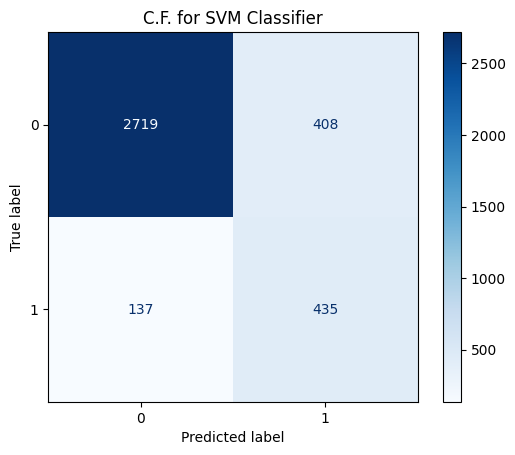

In [170]:
#plotting confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc, cmap="Blues")
plt.title("C.F. for SVM Classifier")
plt.savefig('cf_svm_classifier.png')
plt.show()

# Using Logistic Regression

In [128]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    solver='saga'
)

In [130]:
from sklearn.pipeline import Pipeline

#pipeline
pipe_lr = Pipeline([
    ("preprocess",preprocessor),
    ("model",lr)
])


In [131]:
from sklearn.model_selection import GridSearchCV


param_grid_lr = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.0005, 0.1, 0.5, 1],
        "model__class_weight" : ['balanced', None],
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2", "elasticnet"],
        "model__l1_ratio": [0.2, 0.5, 0.8],
        "model__C": [0.0005, 0.1, 0.5, 1],
        "model__class_weight" : ['balanced', None],

    }
]

grid_lr = GridSearchCV(
    pipe_lr, 
    param_grid_lr,
    scoring = 'recall',
    cv = 5, 
    n_jobs = -1,
    verbose = 2
)


grid_lr.fit(X_train, y_train)  

Fitting 5 folds for each of 88 candidates, totalling 440 fits


,estimator,Pipeline(step...ver='saga'))])
,param_grid,"[{'model__C': [0.0005, 0.1, ...], 'model__class_weight': ['balanced', None], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}, {'model__C': [0.0005, 0.1, ...], 'model__class_weight': ['balanced', None], 'model__l1_ratio': [0.2, 0.5, ...], 'model__penalty': ['l1', 'l2', ...], ...}]"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [147]:
print(grid_lr.best_params_)

{'model__C': 0.0005, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [148]:
best_model_lr = grid_lr.best_estimator_

y_pred_lr = best_model_lr.predict(X_test)

In [149]:
print("Logistic Regression\n")

print("f1_score : ", f1_score(y_test,y_pred_lr))
print("acc_score: ", accuracy_score(y_test,y_pred_lr))
print("precision : ", precision_score(y_test,y_pred_lr))
print("recall : ", recall_score(y_test,y_pred_lr))
print("ROC_AUC : ", roc_auc_score(y_test,y_pred_lr))

print("\nConfusion matrix:\n", confusion_matrix(y_test,y_pred_lr))

Logistic Regression

f1_score :  0.5349112426035503
acc_score:  0.7875101378751014
precision :  0.40429338103756707
recall :  0.7902097902097902
ROC_AUC :  0.7886130498858352

Confusion matrix:
 [[2461  666]
 [ 120  452]]


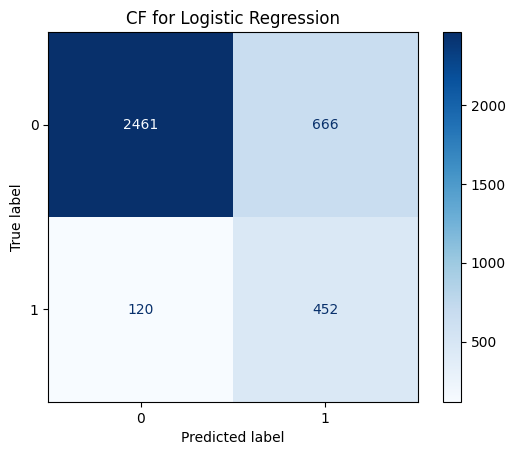

In [171]:
#plotting confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap="Blues")
plt.title("CF for Logistic Regression")
plt.savefig('cf_lr.png')
plt.show()

# Filtering & plotting the most important features

In [176]:
tree = best_model_dt.named_steps["model"]

In [177]:
feature_names = best_model_dt.named_steps["preprocess"].get_feature_names_out()
feature_names

array(['num__Administrative', 'num__Administrative_Duration',
       'num__Informational', 'num__Informational_Duration',
       'num__ProductRelated', 'num__ProductRelated_Duration',
       'num__BounceRates', 'num__ExitRates', 'num__PageValues',
       'num__SpecialDay', 'num__OperatingSystems', 'num__Browser',
       'num__Region', 'num__TrafficType', 'num__VisitorType',
       'num__Weekend', 'cat__Month_Aug', 'cat__Month_Dec',
       'cat__Month_Feb', 'cat__Month_Jul', 'cat__Month_June',
       'cat__Month_Mar', 'cat__Month_May', 'cat__Month_Nov',
       'cat__Month_Oct', 'cat__Month_Sep'], dtype=object)

In [178]:
importance = pd.Series(
    tree.feature_importances_,
    index=feature_names
)

importance = importance.sort_values(ascending=False)
print(importance.head(10))

num__PageValues                 0.853314
cat__Month_Nov                  0.068531
num__ProductRelated_Duration    0.025524
cat__Month_Sep                  0.014150
num__BounceRates                0.012385
cat__Month_Mar                  0.009815
cat__Month_May                  0.007586
num__Administrative             0.005217
num__ExitRates                  0.003479
num__Administrative_Duration    0.000000
dtype: float64


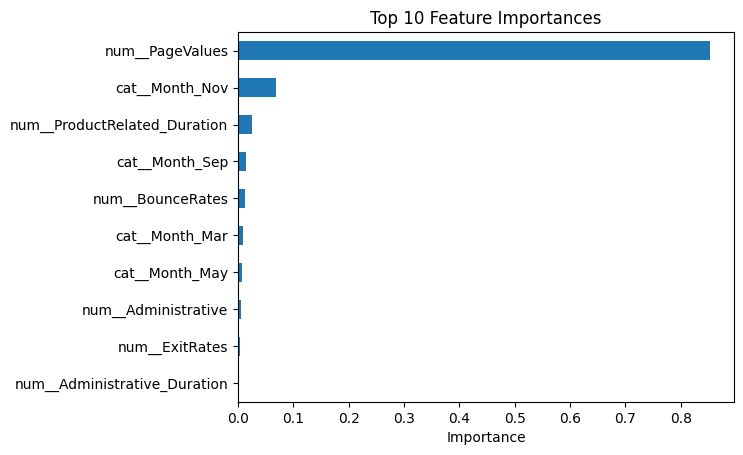

In [185]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.savefig('most_imp_features.png')
plt.show()

# Saving the best Model

In [156]:
import joblib

joblib.dump(best_model_dt, "decision_tree.pkl")

['decision_tree.pkl']